In [ ]:
# ==========================================================
# DIGITAL TWIN INSPIRED CROP SUITABILITY FRAMEWORK
# PART 1 : DATA PREPARATION
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Machine Learning
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Explainability
import shap

# ==========================================================
# REPRODUCIBILITY
# ==========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# ==========================================================
# UPLOAD DATASET
# ==========================================================

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

data = pd.read_csv(file_name)

print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("\nShape :", data.shape)

print("\nFirst Five Records")

display(data.head())

# ==========================================================
# DIGITAL TWIN ABSTRACTION
# ==========================================================

def create_digital_twin_label(row):

    score = 0

    if 20 <= row["temperature"] <= 30:
        score += 1

    if 40 <= row["humidity"] <= 80:
        score += 1

    if 5.5 <= row["ph"] <= 7.5:
        score += 1

    if row["rainfall"] > 50:
        score += 1

    # Small stochastic perturbation
    if random.random() < 0.01:
        return random.choice([0,1,2])

    if score >= 3:
        return 2

    elif score == 2:
        return 1

    else:
        return 0


data["twin_label"] = data.apply(
    create_digital_twin_label,
    axis=1
)

print("\nTwin Label Distribution")

print(data["twin_label"].value_counts())

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

data["temp_humidity_ratio"] = (
    data["temperature"] /
    (data["humidity"] + 1)
)

data["ph_deviation"] = abs(
    data["ph"] - 6.5
)

print("\nFeature Engineering Completed.")

# ==========================================================
# ABLATION FEATURE SETS
# ==========================================================

feature_sets = {

    "Raw Features":

    [
        "temperature",
        "humidity",
        "ph",
        "rainfall"
    ],

    "Raw + Feature Engineering":

    [
        "temperature",
        "humidity",
        "ph",
        "rainfall",
        "temp_humidity_ratio",
        "ph_deviation"
    ],

    "Abstraction Only":

    [
        "temperature",
        "humidity",
        "ph",
        "rainfall"
    ],

    "Abstraction + Decoupling":

    [
        "temperature",
        "humidity",
        "ph",
        "temp_humidity_ratio",
        "ph_deviation"
    ],

    "Proposed Framework":

    [
        "temperature",
        "humidity",
        "ph",
        "rainfall",
        "temp_humidity_ratio",
        "ph_deviation"
    ]
}

# ==========================================================
# TARGET VARIABLE
# ==========================================================

y = data["twin_label"]

print("\nTarget Classes")

print(y.value_counts())

# ==========================================================
# STRATIFIED 5-FOLD CROSS VALIDATION
# ==========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

TOTAL_FOLDS = 25
print("\n5-Fold Stratified Cross Validation Initialized.")

# ==========================================================
# MODELS
# ==========================================================

models = {

    "Random Forest":

    RandomForestClassifier(
        random_state=SEED
    ),

    "XGBoost":

    XGBClassifier(
        random_state=SEED,
        eval_metric="mlogloss"
    ),

    "Gradient Boosting":

    GradientBoostingClassifier(
        random_state=SEED
    )
}

print("\nModels Ready")

for name in models.keys():
    print(name)



Saving Crop_recommendation.csv to Crop_recommendation (2).csv
DATASET INFORMATION

Shape : (2200, 8)

First Five Records


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



Twin Label Distribution
twin_label
2    1436
1     687
0      77
Name: count, dtype: int64

Feature Engineering Completed.

Target Classes
twin_label
2    1436
1     687
0      77
Name: count, dtype: int64

5-Fold Stratified Cross Validation Initialized.

Models Ready
Random Forest
XGBoost
Gradient Boosting


In [ ]:
def evaluate_model_cv(model, X, y, cv):

    accuracy_list = []
    precision_list = []
    recall_list = []
    f1_list = []
    auc_list = []
    specificity_list = []

    all_y_true = []
    all_y_pred = []
    all_y_prob = []

    classes = np.unique(y)

    fold = 1

    for train_idx, test_idx in cv.split(X, y):

        print(f"Processing Fold {fold}/{cv.get_n_splits()}")

        # -------------------------------
        # Split Data
        # -------------------------------

        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # -------------------------------
        # Standardization
        # -------------------------------

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # -------------------------------
        # Train
        # -------------------------------

        model.fit(X_train, y_train)

        # -------------------------------
        # Prediction
        # -------------------------------

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        # Store results

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)
        all_y_prob.append(y_prob)

        # -------------------------------
        # Metrics
        # -------------------------------

        accuracy_list.append(
            accuracy_score(y_test, y_pred)
        )

        precision_list.append(
            precision_score(
                y_test,
                y_pred,
                average="macro",
                zero_division=0
            )
        )

        recall_list.append(
            recall_score(
                y_test,
                y_pred,
                average="macro",
                zero_division=0
            )
        )

        f1_list.append(
            f1_score(
                y_test,
                y_pred,
                average="macro",
                zero_division=0
            )
        )

                # -------------------------------
        # Specificity (Macro Average)
        # -------------------------------

        cm_fold = confusion_matrix(y_test, y_pred)

        specificities = []

        for i in range(len(classes)):

            TP = cm_fold[i, i]

            FN = np.sum(cm_fold[i, :]) - TP

            FP = np.sum(cm_fold[:, i]) - TP

            TN = np.sum(cm_fold) - TP - FP - FN

            if (TN + FP) == 0:
                specificity = 0
            else:
                specificity = TN / (TN + FP)

            specificities.append(specificity)

        specificity_list.append(np.mean(specificities))

        auc_list.append(
            roc_auc_score(
                label_binarize(y_test, classes=classes),
                y_prob,
                multi_class="ovr",
                average="macro"
            )
        )

        fold += 1


    # =========================================================
    # Overall Confusion Matrix
    # =========================================================

    cm = confusion_matrix(all_y_true, all_y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predicted Class", fontsize=12)
    plt.ylabel("True Class", fontsize=12)
    plt.title("Overall Confusion Matrix", fontsize=14)
    plt.tight_layout()
    plt.show()


    # =========================================================
    # Overall ROC Curve
    # =========================================================

    all_y_prob = np.vstack(all_y_prob)

    y_true_bin = label_binarize(
        all_y_true,
        classes=classes
    )

    plt.figure(figsize=(8,6))

    for i in range(len(classes)):

        fpr, tpr, _ = roc_curve(
            y_true_bin[:, i],
            all_y_prob[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"Class {classes[i]} (AUC={roc_auc:.3f})"
        )

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--",
        linewidth=2,
        color="black"
    )

    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title("Multi-class ROC Curve", fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # =========================================================
    # Return Results
    # =========================================================

    return {

        "Accuracy Mean": np.mean(accuracy_list),
        "Accuracy Std": np.std(accuracy_list),

        "Precision Mean": np.mean(precision_list),
        "Precision Std": np.std(precision_list),

        "Recall Mean": np.mean(recall_list),
        "Recall Std": np.std(recall_list),

        "Specificity Mean": np.mean(specificity_list),
        "Specificity Std": np.std(specificity_list),

        "F1 Mean": np.mean(f1_list),
        "F1 Std": np.std(f1_list),

        "AUC Mean": np.mean(auc_list),
        "AUC Std": np.std(auc_list)
    }

MODEL COMPARISON USING 5-FOLD STRATIFIED CROSS VALIDATION

Evaluating : Random Forest
Processing Fold 1/5
Processing Fold 2/5
Processing Fold 3/5
Processing Fold 4/5
Processing Fold 5/5


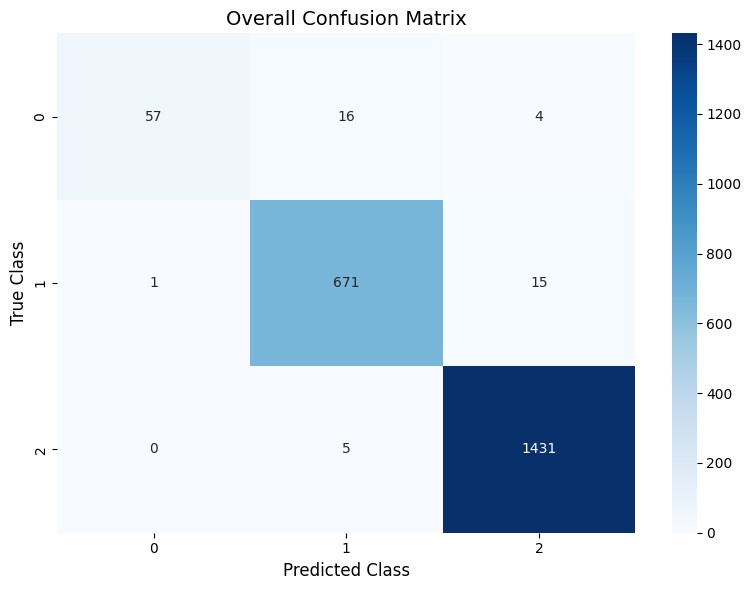

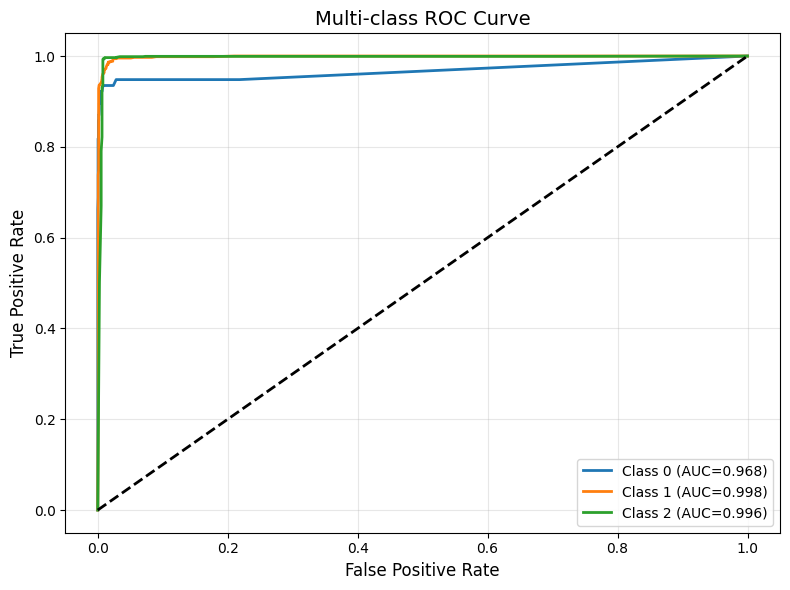


Evaluating : XGBoost
Processing Fold 1/5
Processing Fold 2/5
Processing Fold 3/5
Processing Fold 4/5
Processing Fold 5/5


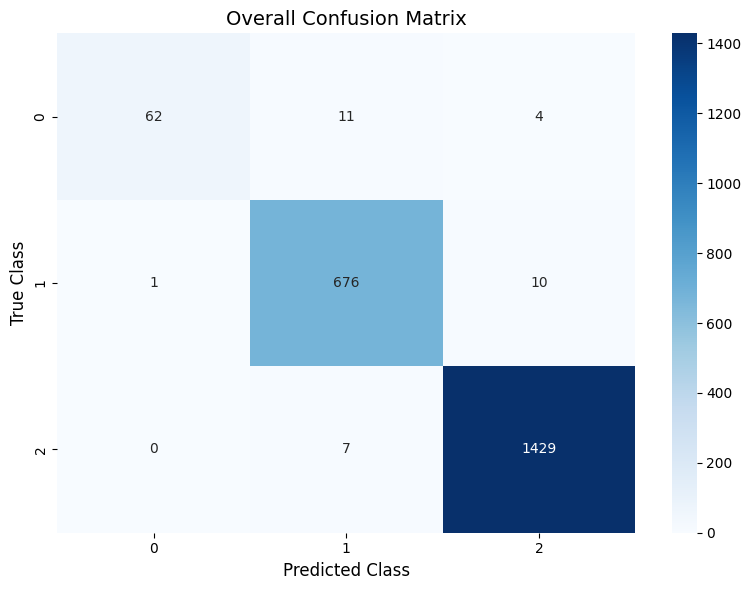

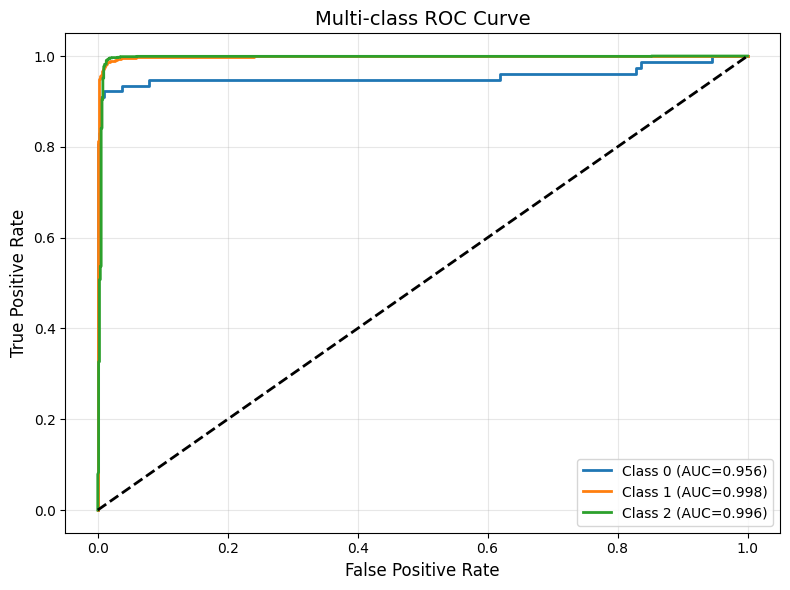


Evaluating : Gradient Boosting
Processing Fold 1/5
Processing Fold 2/5
Processing Fold 3/5
Processing Fold 4/5
Processing Fold 5/5


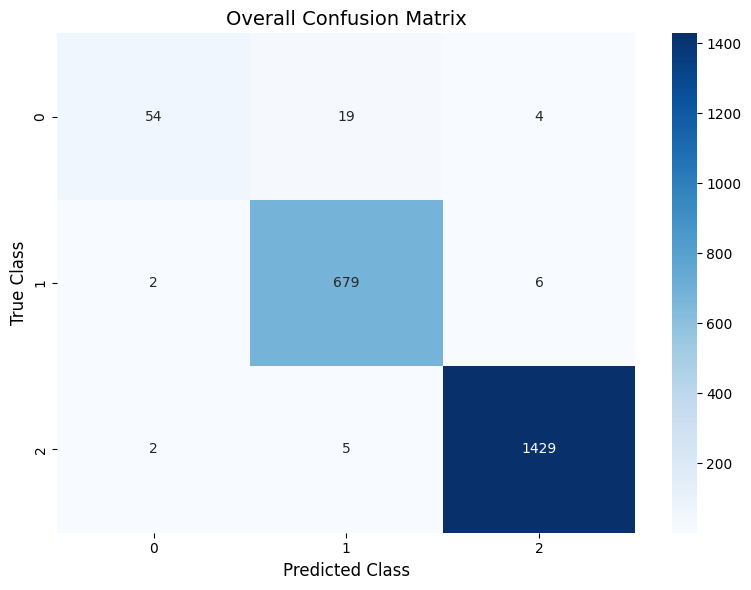

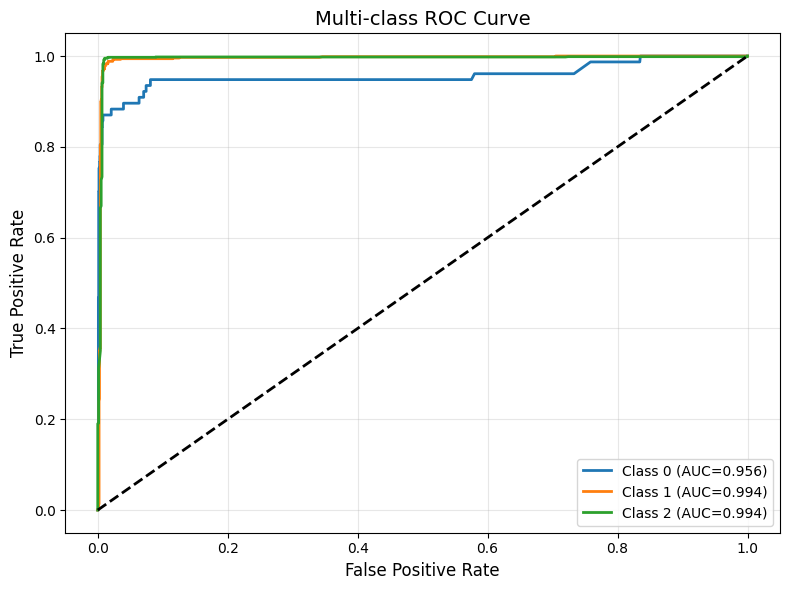



FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,Specificity,F1-score,AUC
0,Random Forest,98.14 ± 0.22,98.08 ± 0.99,90.41 ± 1.41,98.69 ± 0.06,93.60 ± 0.84,98.76 ± 1.42
1,XGBoost,98.50 ± 0.40,98.40 ± 0.61,92.78 ± 3.09,98.98 ± 0.30,95.14 ± 1.76,98.43 ± 1.72
2,Gradient Boosting,98.27 ± 0.42,96.37 ± 2.40,89.45 ± 3.78,98.97 ± 0.26,92.20 ± 2.97,98.34 ± 1.57



Results saved as Model_Comparison_5FoldCV.csv


In [ ]:
# ==========================================================
# PART 3 : MODEL COMPARISON USING 5-FOLD CV
# ==========================================================

print("="*70)
print("MODEL COMPARISON USING 5-FOLD STRATIFIED CROSS VALIDATION")
print("="*70)

# ----------------------------------------------------------
# Proposed Framework Features
# ----------------------------------------------------------

X = data[feature_sets["Proposed Framework"]]

results = []

# ----------------------------------------------------------
# Evaluate Each Model
# ----------------------------------------------------------

for model_name, model in models.items():

    print("\n" + "="*60)
    print(f"Evaluating : {model_name}")
    print("="*60)

    metrics = evaluate_model_cv(model, X, y, cv)

    results.append({

        "Model": model_name,

        "Accuracy":
        f"{metrics['Accuracy Mean']*100:.2f} ± {metrics['Accuracy Std']*100:.2f}",

        "Precision":
        f"{metrics['Precision Mean']*100:.2f} ± {metrics['Precision Std']*100:.2f}",

        "Recall":
        f"{metrics['Recall Mean']*100:.2f} ± {metrics['Recall Std']*100:.2f}",

         "Specificity":
        f"{metrics['Specificity Mean']*100:.2f} ± {metrics['Specificity Std']*100:.2f}",

        "F1-score":
        f"{metrics['F1 Mean']*100:.2f} ± {metrics['F1 Std']*100:.2f}",

        "AUC":
        f"{metrics['AUC Mean']*100:.2f} ± {metrics['AUC Std']*100:.2f}"

    })

# ----------------------------------------------------------
# Results Table
# ----------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n")
print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

display(results_df)

# ----------------------------------------------------------
# Save CSV
# ----------------------------------------------------------

results_df.to_csv(
    "Model_Comparison_5FoldCV.csv",
    index=False
)

print("\nResults saved as Model_Comparison_5FoldCV.csv")

In [ ]:
# ==========================================================
# ABLATION FEATURE SETS
# ==========================================================

feature_sets = {

    "Raw Features":[
        "temperature",
        "humidity",
        "ph",
        "rainfall"
    ],

    "Raw + Feature Engineering":[
        "temperature",
        "humidity",
        "ph",
        "rainfall",
        "temp_humidity_ratio",
        "ph_deviation"
    ],

    # Digital Twin abstraction represented by twin_label generation
    # Use only the environmental variables
    "Abstraction Only":[
        "temperature",
        "humidity",
        "ph",
        "rainfall"
    ],

    # Decoupling removes rainfall
    "Abstraction + Decoupling":[
        "temperature",
        "humidity",
        "ph",
        "temp_humidity_ratio",
        "ph_deviation"
    ],

    # Proposed framework keeps all engineered information
    "Proposed Framework":[
        "temperature",
        "humidity",
        "ph",
        "rainfall",
        "temp_humidity_ratio",
        "ph_deviation"
    ]
}

ABLATION STUDY

Raw Features
Processing Fold 1/5
Processing Fold 2/5
Processing Fold 3/5
Processing Fold 4/5
Processing Fold 5/5


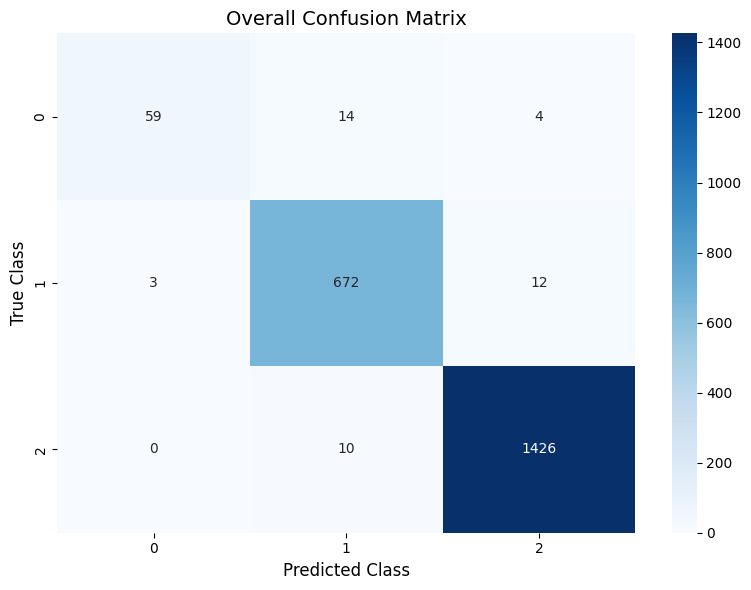

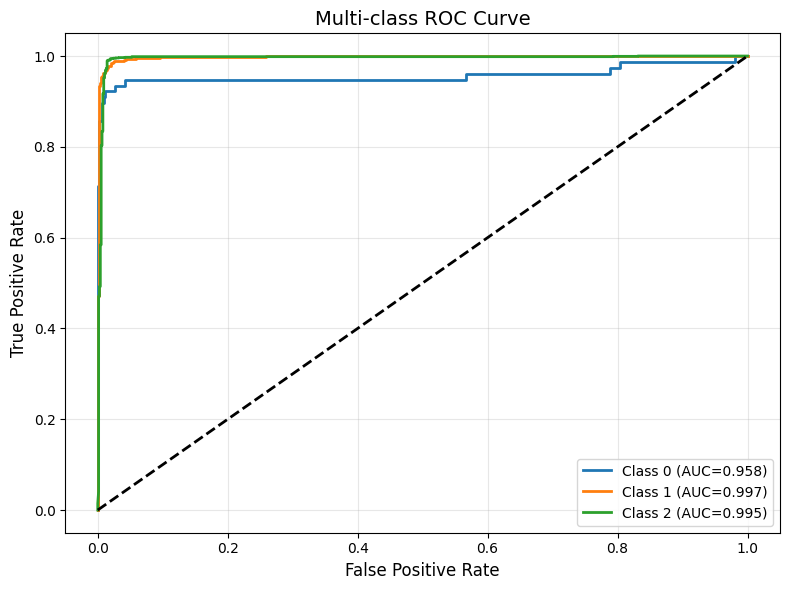


Raw + Feature Engineering
Processing Fold 1/5
Processing Fold 2/5
Processing Fold 3/5
Processing Fold 4/5
Processing Fold 5/5


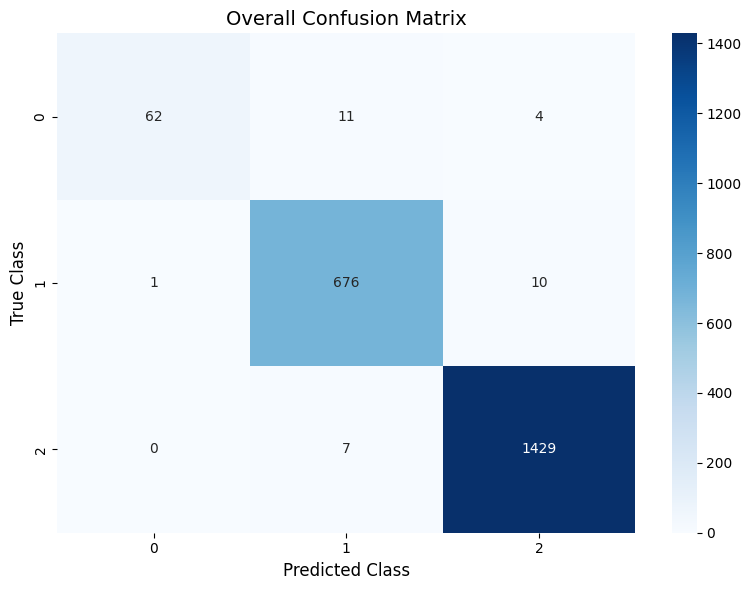

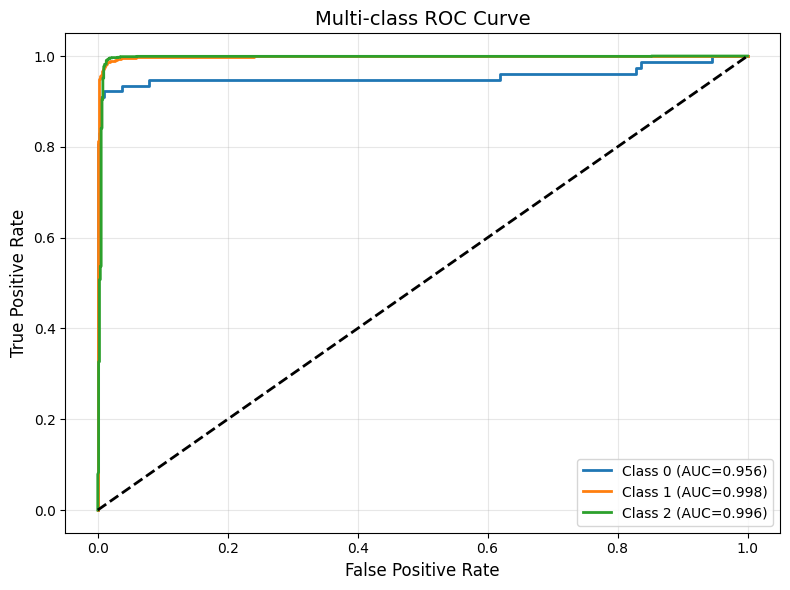


Abstraction Only
Processing Fold 1/5
Processing Fold 2/5
Processing Fold 3/5
Processing Fold 4/5
Processing Fold 5/5


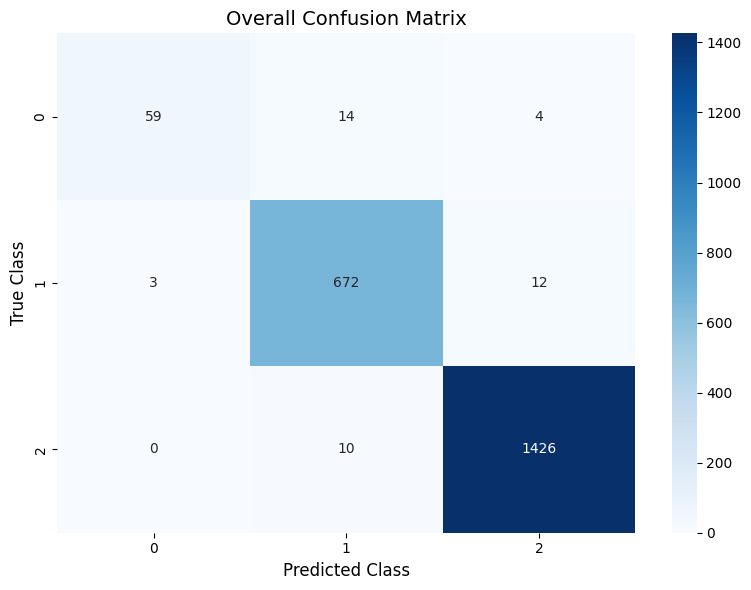

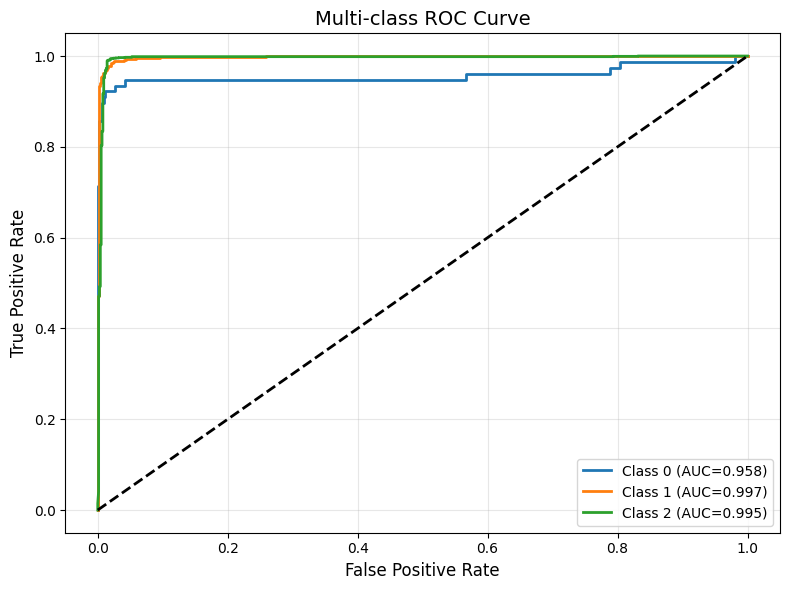


Abstraction + Decoupling
Processing Fold 1/5
Processing Fold 2/5
Processing Fold 3/5
Processing Fold 4/5
Processing Fold 5/5


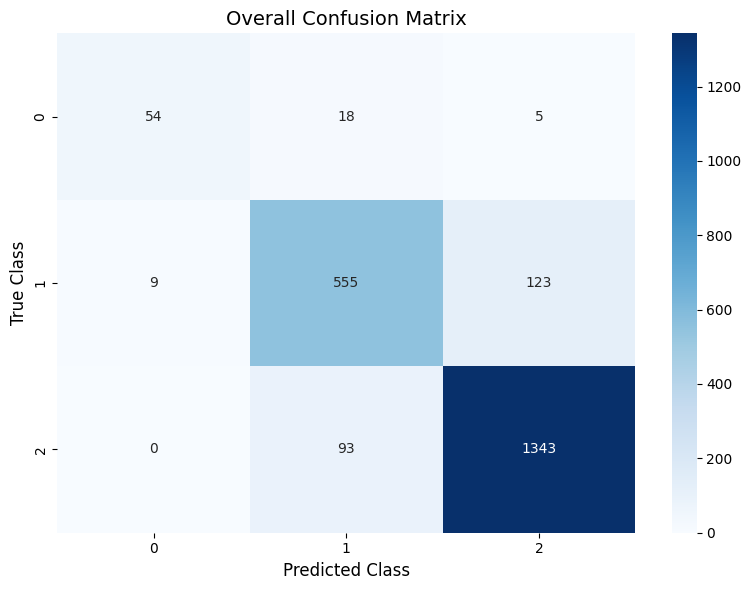

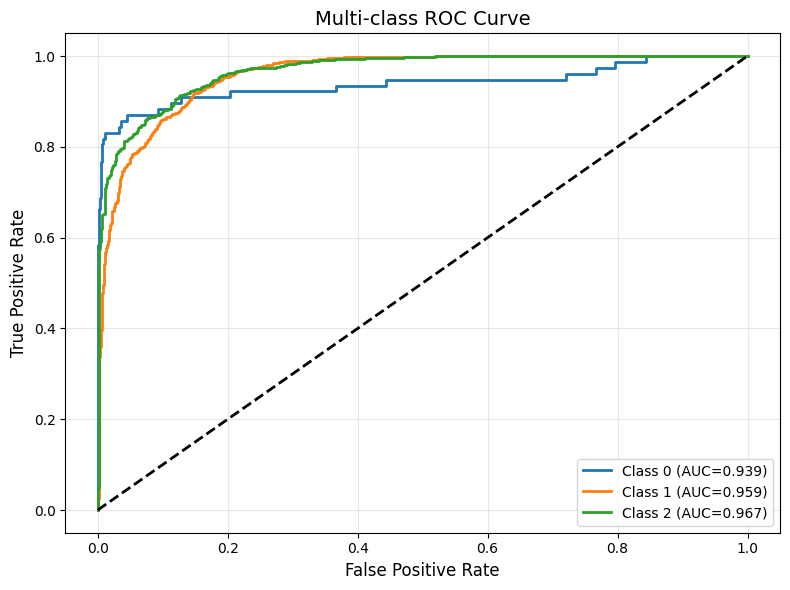


Proposed Framework
Processing Fold 1/5
Processing Fold 2/5
Processing Fold 3/5
Processing Fold 4/5
Processing Fold 5/5


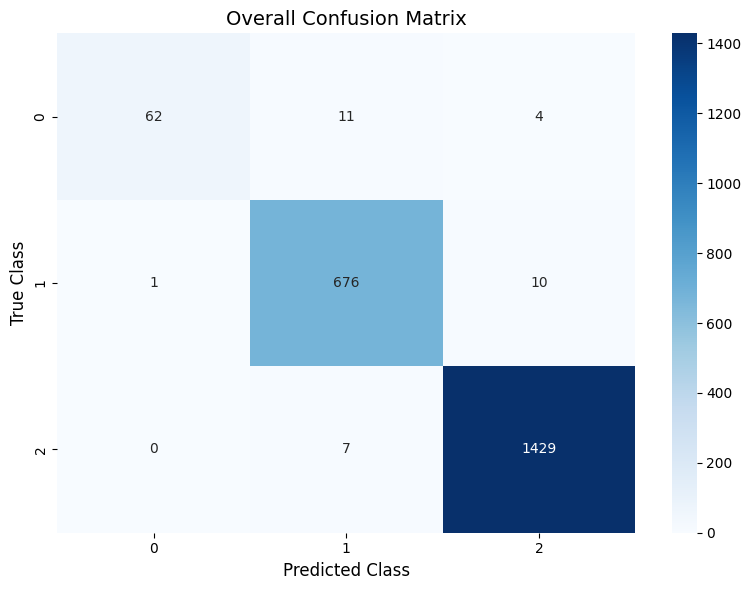

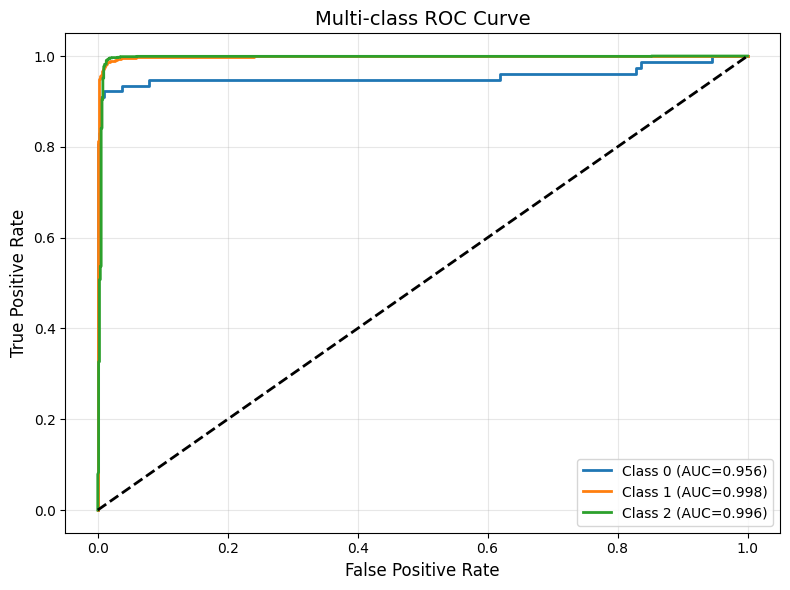

,Configuration,Accuracy,Precision,Recall,Specificity,F1,AUC
0,Raw Features,0.9805,0.9696,0.9115,0.9873,0.9352,0.9840
1,Raw + Feature Engineering,0.9850,0.9840,0.9278,0.9898,0.9514,0.9843
2,Abstraction Only,0.9805,0.9696,0.9115,0.9873,0.9352,0.9840
3,Abstraction + Decoupling,0.8873,0.8727,0.8146,0.9183,0.8368,0.9561
4,Proposed Framework,0.9850,0.9840,0.9278,0.9898,0.9514,0.9843



Ablation Study Saved.


In [ ]:
# ==========================================================
# PART 4 : ABLATION STUDY
# ==========================================================

print("="*70)
print("ABLATION STUDY")
print("="*70)

ablation_results = []

# Proposed Model
ablation_model = XGBClassifier(
    random_state=SEED
)

for experiment, feature_list in feature_sets.items():

    print("\n" + "="*60)
    print(experiment)
    print("="*60)

    X = data[feature_list]

    metrics = evaluate_model_cv(
        ablation_model,
        X,
        y,
        cv
    )

    ablation_results.append({

        "Configuration": experiment,

        "Accuracy":
        metrics["Accuracy Mean"],

        "Precision":
        metrics["Precision Mean"],

        "Recall":
        metrics["Recall Mean"],

        "Specificity":
        metrics["Specificity Mean"],

        "F1":
        metrics["F1 Mean"],

        "AUC":
        metrics["AUC Mean"]

    })

# ==========================================================
# RESULTS TABLE
# ==========================================================

ablation_df = pd.DataFrame(ablation_results)

display(

    ablation_df.style.format({

        "Accuracy":"{:.4f}",
        "Precision":"{:.4f}",
        "Recall":"{:.4f}",
        "Specificity":"{:.4f}",
        "F1":"{:.4f}",
        "AUC":"{:.4f}"

    })

)

ablation_df.to_csv(
    "Ablation_Study.csv",
    index=False
)

print("\nAblation Study Saved.")

In [ ]:
# ==========================================================
# PART 5 : SHAP ANALYSIS FOR XGBOOST
# ==========================================================

import shap

print("="*70)
print("SHAP EXPLAINABILITY ANALYSIS (XGBoost)")
print("="*70)

# ----------------------------------------------------------
# Proposed Framework Features
# ----------------------------------------------------------

X = data[feature_sets["Proposed Framework"]]

# ----------------------------------------------------------
# Feature Scaling
# ----------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# ----------------------------------------------------------
# Train Final XGBoost Model
# ----------------------------------------------------------

best_model = XGBClassifier(
    random_state=SEED,
    eval_metric='mlogloss'
)

best_model.fit(X_scaled, y)

print("Final XGBoost Model Trained Successfully")

SHAP EXPLAINABILITY ANALYSIS (XGBoost)
Final XGBoost Model Trained Successfully


In [ ]:
# ==========================================================
# COMPUTE SHAP VALUES
# ==========================================================

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_scaled)

print("SHAP values generated successfully.")

SHAP values generated successfully.


In [ ]:
import shap
print(shap.__version__)

0.52.0


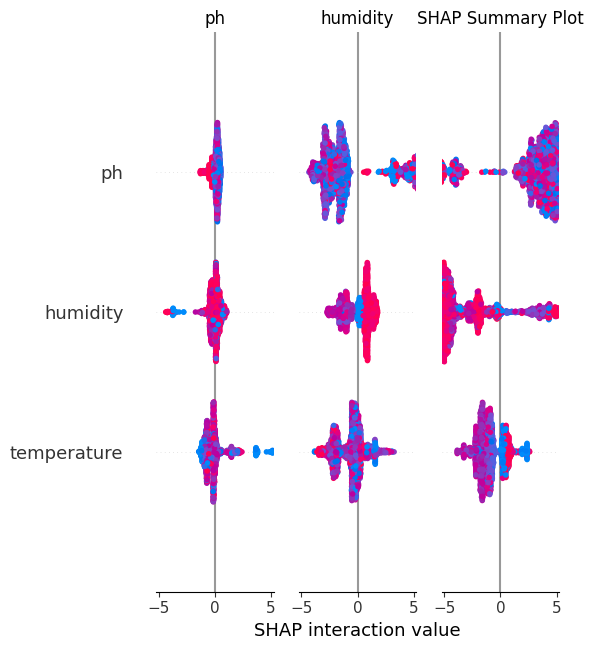

In [ ]:
# ==========================================================
# SHAP SUMMARY PLOT
# ==========================================================

shap.summary_plot(
    shap_values,
    X_scaled,
    feature_names=X.columns,
    show=False
)

plt.title("SHAP Summary Plot")

plt.tight_layout()

plt.show()

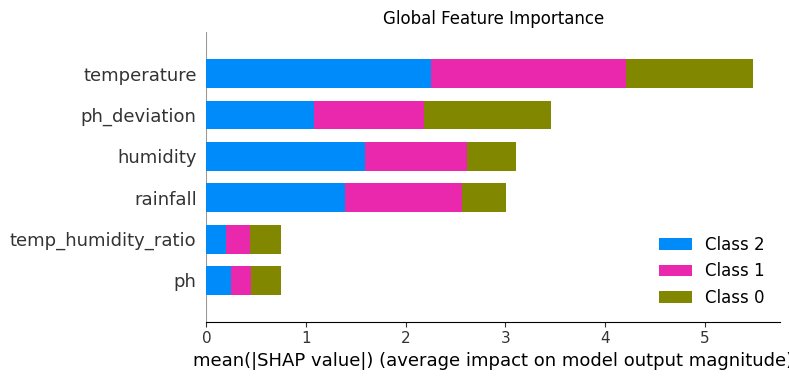

In [ ]:
# ==========================================================
# SHAP FEATURE IMPORTANCE
# ==========================================================

shap.summary_plot(
    shap_values,
    X_scaled,
    feature_names=X.columns,
    plot_type="bar",
    show=False
)

plt.title("Global Feature Importance")

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# SHAP FEATURE RANKING (SHAP >= 0.45)
# ==========================================================

importance = np.mean(
    np.abs(shap_values),
    axis=(0, 2)      # average over samples and classes
)

shap_df = pd.DataFrame({
    "Feature": X.columns,
    "Mean |SHAP|": importance
})

shap_df = shap_df.sort_values(
    by="Mean |SHAP|",
    ascending=False
)

display(shap_df)

shap_df.to_csv(
    "SHAP_Feature_Importance.csv",
    index=False
)

,Feature,Mean |SHAP|
0,temperature,1.827057
5,ph_deviation,1.152465
1,humidity,1.036178
3,rainfall,1.000510
4,temp_humidity_ratio,0.248367
2,ph,0.248289


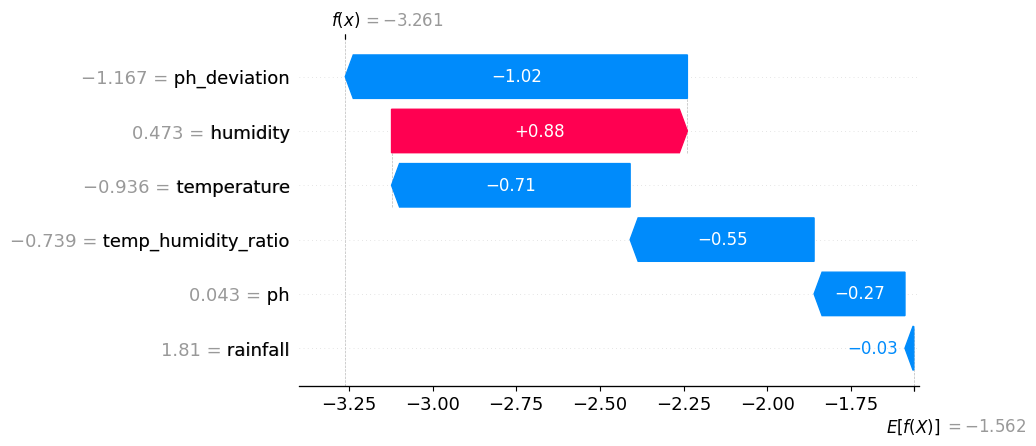

In [ ]:
sample = 0
class_id = 0

exp = shap.Explanation(
    values=shap_values[sample,:,class_id],
    base_values=explainer.expected_value[class_id],
    data=X_scaled.iloc[sample],
    feature_names=X.columns.tolist()
)

shap.plots.waterfall(exp)

In [ ]:
sample = 0
class_id = 0

shap.initjs()

shap.force_plot(
    explainer.expected_value[class_id],
    shap_values[sample,:,class_id],
    X_scaled.iloc[sample]
)

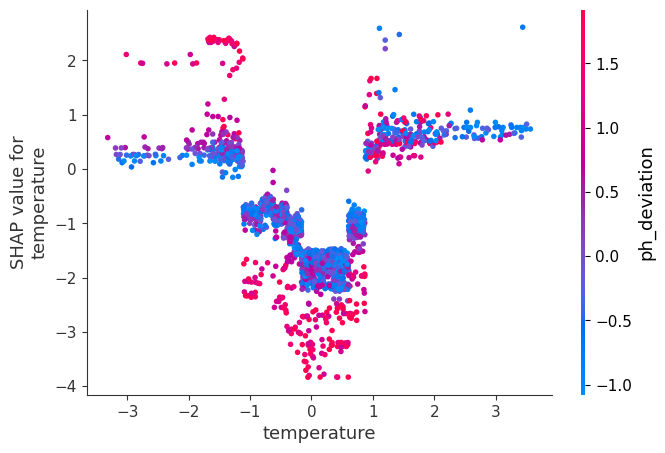

In [ ]:
top_feature = shap_df.iloc[0]["Feature"]

shap.dependence_plot(
    top_feature,
    shap_values[:,:,0],      # Class 0
    X_scaled,
    feature_names=X.columns
)